In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib as mpl
import numpy as np
import math
import time

plt.rcParams['figure.figsize'] = (16, 16)

### Functions

In [2]:
# TODO: import from ifs.py
def codes(m, n):
    l = 0
    codes = []
    while l < m**n:
        k = l
        j = n - 1
        expan = []
        while j >= 0:
            expan.append(k // (m**j))
            if k // (m**j) != 0:
                k = k % (m**j)
            j -= 1
        l += 1
        codes.append(expan)
    return np.array(codes)

In [117]:
# TODO: fix aspect ratio
# TODO: dummy-proof?
# TODO: import from ifs.py

def plot(ifs, clicks, n = 0, grid = None, xlim = [0,1], ylim = [0,1], color = 'k'):
    
    
    if grid == None:
        multiplot = False
        nrows = 1
        ncols = 1
    else:   
        multiplot = True
        nrows = grid[0]
        ncols = grid[1]
    
    fig, axs = plt.subplots(nrows = nrows, ncols = ncols)
    
    if nrows == 1 & ncols == 1:
        axs = np.array([axs])
    else:
        axs = axs.ravel()
    
    for ax in axs:
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
    
    m = len(ifs)
    
    start = time.perf_counter()

    if multiplot == True:      
        
        for j, ax in enumerate(axs):  
            
            for code in codes(m, j):
                
                t = mpl.transforms.IdentityTransform()
                
                for i in code:
                    t += ifs[i]
                    
                ax.add_patch(mpl.patches.Polygon(t.transform(clicks), facecolor = color))
            
            end = time.perf_counter()
            print('Iteration ' + str(j) + ' took ' + str(end - start) + ' seconds.') 
    else:      
        
        ax = axs[0]
        
        t = mpl.transforms.IdentityTransform()
        
        for code in codes(m, n):
            
            t = mpl.transforms.IdentityTransform()
            
            for i in code:
                    t += ifs[i]
        
            ax.add_patch(mpl.patches.Polygon(t.transform(clicks), facecolor = color))
        
        end = time.perf_counter()
        print('Iteration ' + str(n) + ' took ' + str(end - start) + ' seconds.')
        
    plt.show()    
    
    end = time.perf_counter()
    print('The whole cell took ' + str(end - start) + ' seconds.')

### Example

Iteration 0 took 0.000305800000205636 seconds.
Iteration 1 took 0.0015012000003480352 seconds.
Iteration 2 took 0.0037639000001945533 seconds.
Iteration 3 took 0.009519400000499445 seconds.
Iteration 4 took 0.028115600000091945 seconds.
Iteration 5 took 0.08610229999976582 seconds.
Iteration 6 took 0.2657636000003549 seconds.
Iteration 7 took 1.010305800000424 seconds.
Iteration 8 took 3.1910612000010588 seconds.


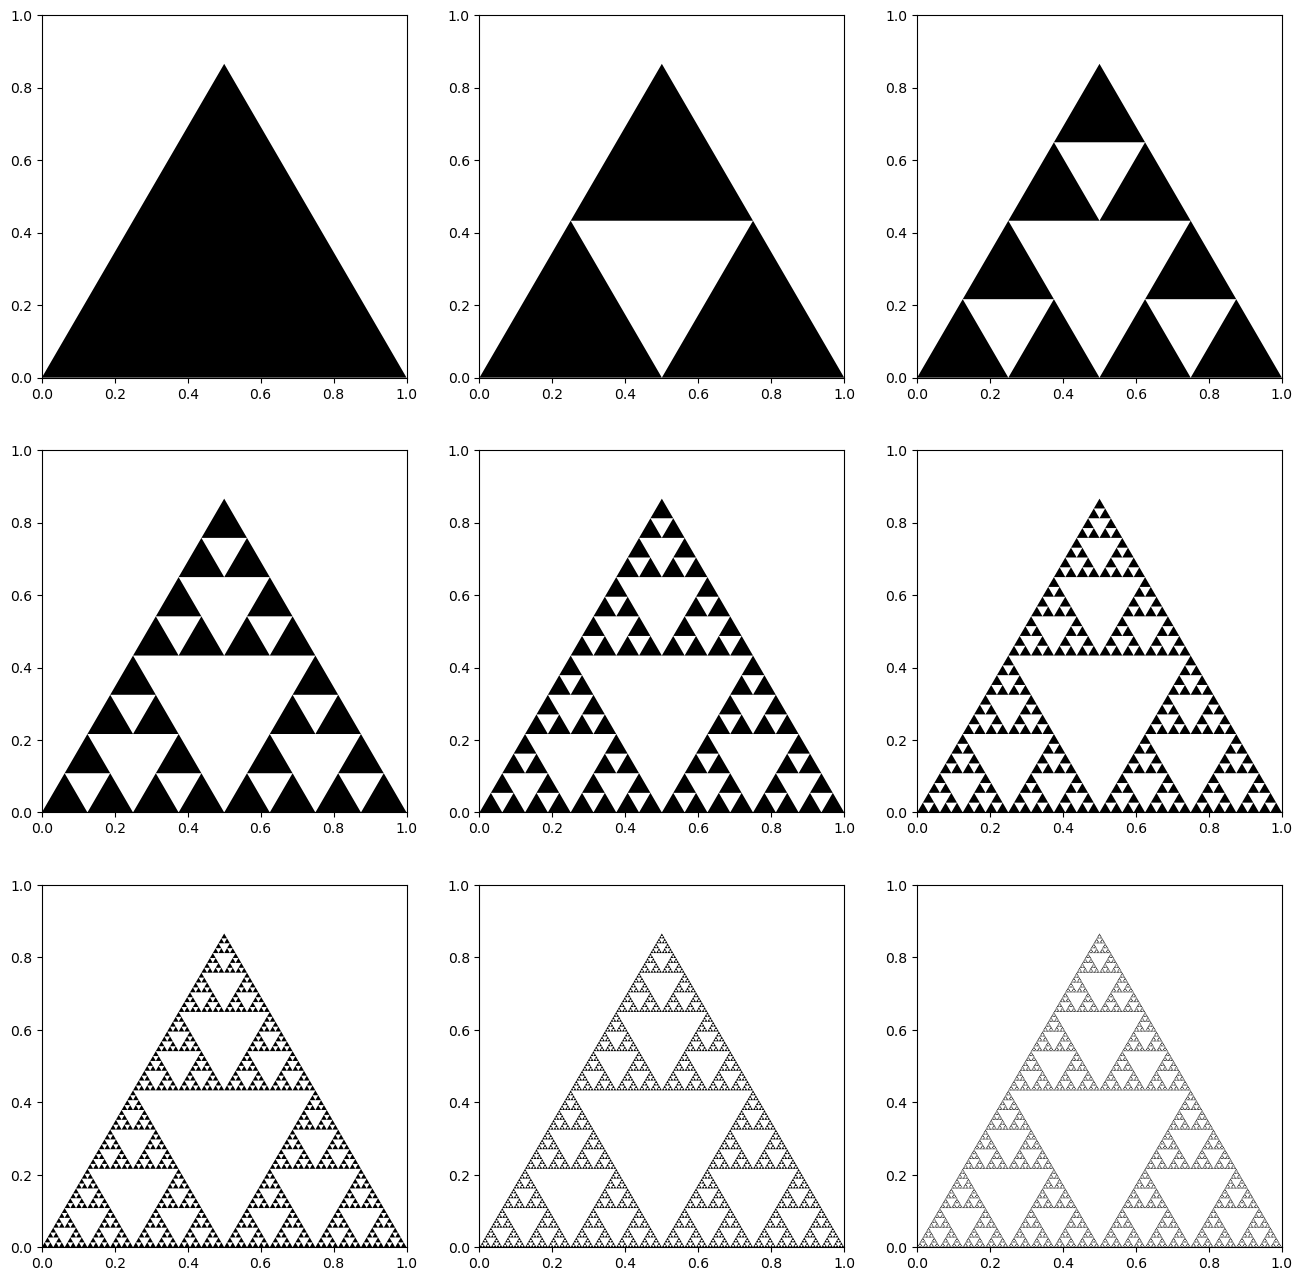

The whole cell took 7.53695400000106 seconds.


In [119]:
#Input the IFS functions    

t0 = mpl.transforms.Affine2D().scale(0.5)
t1 = mpl.transforms.Affine2D().translate(1, 0) + mpl.transforms.Affine2D().scale(0.5)
t2 = mpl.transforms.Affine2D().translate(0.5, np.sqrt(3)/2) + mpl.transforms.Affine2D().scale(0.5)

ifs = [t0, t1, t2]

#Input the vertices for the starting set

clicks = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
color = 'b'

#Plot the attractor 

#plot(ifs, clicks)  # starting set
#plot(ifs, clicks, n = 5)  # one plot with n iterations
plot(ifs, clicks, grid = (3,3))  # successive iterations in a grid

### TODO: update these examples to use plot(ifs, clicks, n=0, grid=None)

Iteration 0 took 0.00193319999925734 seconds.
Iteration 1 took 0.007792599999447702 seconds.
Iteration 2 took 0.022197599999344675 seconds.
Iteration 3 took 0.06530299999940326 seconds.
Iteration 4 took 0.22902020000037737 seconds.
Iteration 5 took 0.692320699999982 seconds.
Iteration 6 took 2.4756739000004018 seconds.
Iteration 7 took 6.614252800000031 seconds.
Iteration 8 took 21.62551220000023 seconds.


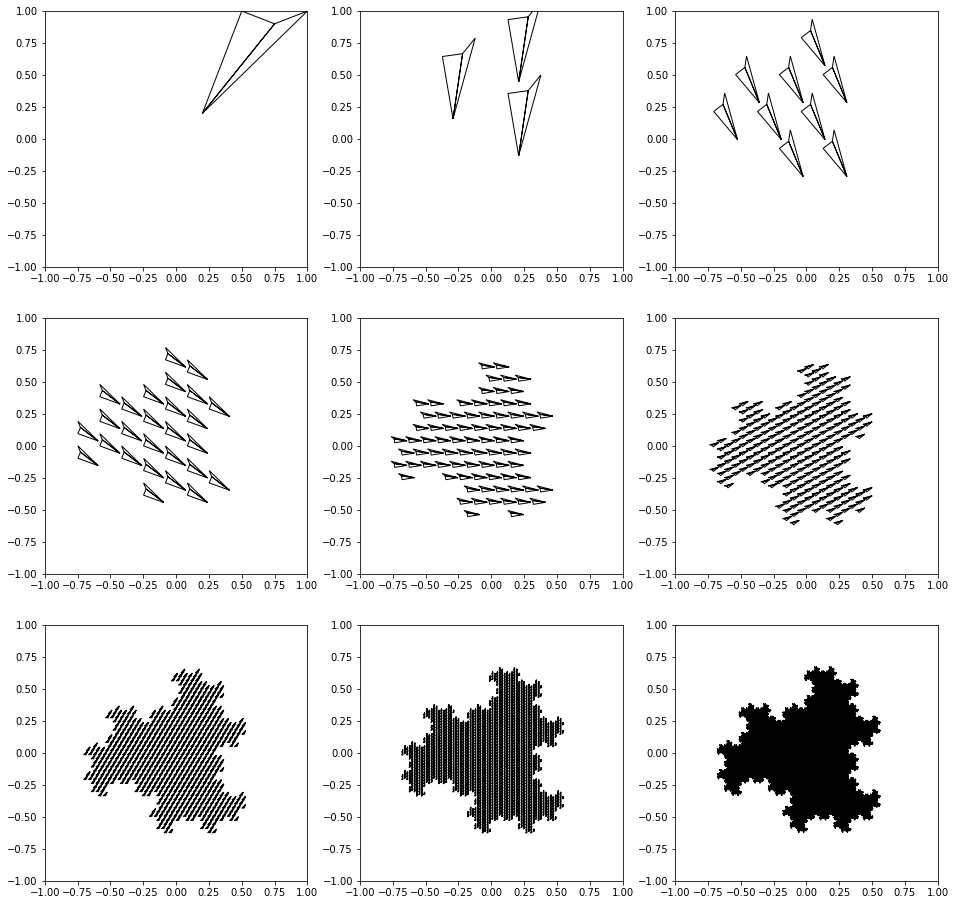

The whole cell took 30.805641199998718 seconds.


In [45]:
import matplotlib as mpl

fig, ax = plt.subplots(nrows = 3, ncols = 3)

for i in range(9):
    ax[i // 3, i % 3].set_xlim([-1, 1])
    ax[i // 3, i % 3].set_ylim([-1, 1])

clicks = np.array([[0.2, 0.2], [1, 1], [0.75, 0.9], [0.2, 0.2], [0.75, 0.9], [0.5, 1]])

lamda = 1/np.sqrt(3)

t0 = mpl.transforms.Affine2D().rotate(np.pi/6) + mpl.transforms.Affine2D().scale(lamda) + mpl.transforms.Affine2D().translate(-1/3, 0)
t1 = mpl.transforms.Affine2D().rotate(np.pi/6) + mpl.transforms.Affine2D().scale(lamda) + mpl.transforms.Affine2D().translate(0.5*(1/3), (np.sqrt(3)/2)*(1/3))
t2 = mpl.transforms.Affine2D().rotate(np.pi/6) + mpl.transforms.Affine2D().scale(lamda) + mpl.transforms.Affine2D().translate(0.5*(1/3), -(np.sqrt(3)/2)*(1/3))

ifsTransforms = [t0, t1, t2]
m = len(ifsTransforms)  

start = time.perf_counter()

for j in range(9):
    for code in codes(m, j):
        t = mpl.transforms.IdentityTransform()
        for i in code:
            t += ifsTransforms[i]
        ax[j // 3, j % 3].add_patch(mpl.patches.Polygon(t.transform(clicks), facecolor = 'w', edgecolor = 'k'))
    end = time.perf_counter()
    print('Iteration ' + str(j) + ' took ' + str(end - start) + ' seconds.')

plt.show()
end = time.perf_counter()
print('The whole cell took ' + str(end - start) + ' seconds.')

Iteration 0 took 0.001901799999927789 seconds.
Iteration 1 took 0.005991999999992004 seconds.
Iteration 2 took 0.013307299999951283 seconds.
Iteration 3 took 0.02670269999998709 seconds.
Iteration 4 took 0.052699500000017 seconds.
Iteration 5 took 0.1254570999999487 seconds.
Iteration 6 took 0.2667744999999968 seconds.
Iteration 7 took 0.5041960999999446 seconds.
Iteration 8 took 1.1441659999999274 seconds.
Iteration 9 took 2.0737739999999576 seconds.
Iteration 10 took 4.144193799999925 seconds.
Iteration 11 took 8.28393589999996 seconds.


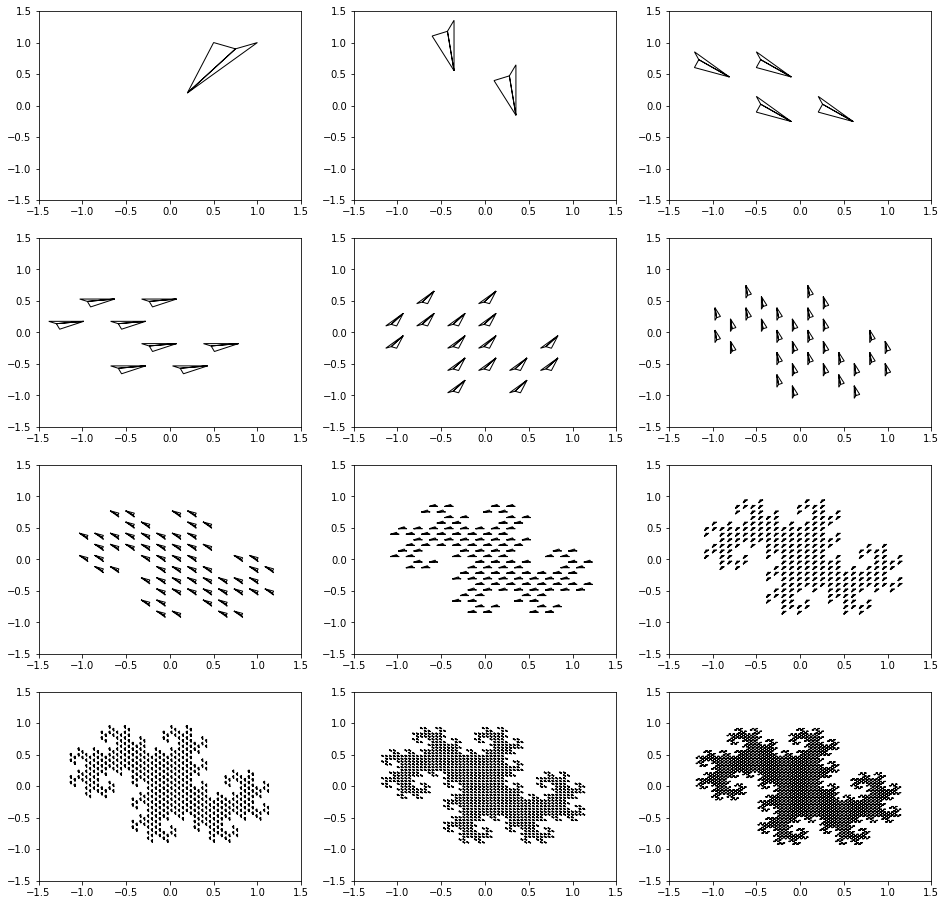

The whole cell took 13.51296549999995 seconds.


In [10]:
import matplotlib as mpl

fig, ax = plt.subplots(nrows = 4, ncols = 3)

for i in range(12):
    ax[i // 3, i % 3].set_xlim([-1.5, 1.5])
    ax[i // 3, i % 3].set_ylim([-1.5, 1.5])

clicks = np.array([[0.2, 0.2], [1, 1], [0.75, 0.9], [0.2, 0.2], [0.75, 0.9], [0.5, 1]])

lamda = 1/np.sqrt(2)

t0 = mpl.transforms.Affine2D().rotate(np.pi/4) + mpl.transforms.Affine2D().translate(-0.5, 0.5) + mpl.transforms.Affine2D().scale(lamda)
t1 = mpl.transforms.Affine2D().rotate(np.pi/4) + mpl.transforms.Affine2D().translate(0.5, -0.5) + mpl.transforms.Affine2D().scale(lamda)

ifsTransforms = [t0, t1]
m = len(ifsTransforms)    
start = time.perf_counter()

for j in range(12):
    for code in codes(m, j):
        t = mpl.transforms.IdentityTransform()
        for i in code:
            t += ifsTransforms[i]
        ax[j // 3, j % 3].add_patch(mpl.patches.Polygon(t.transform(clicks), facecolor = 'w', edgecolor = 'k'))
    end = time.perf_counter()
    print('Iteration ' + str(j) + ' took ' + str(end - start) + ' seconds.')

plt.show()
end = time.perf_counter()
print('The whole cell took ' + str(end - start) + ' seconds.')